In [1]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

WORK_DIR = "/kaggle/working"
DATA_PATH = "/kaggle/input/datasets/trngtnhng/chatbotdat/router_dataset_vi_clean.csv"  # chỉnh đúng tên dataset bên Input

LABEL_NAMES = [
    "normal_support",
    "school_stress",
    "relationship_issue",
    "self_care",
    "high_risk",
]
SEED = 42

df = pd.read_csv(DATA_PATH)
df = df[df["label"].isin(LABEL_NAMES)].dropna(subset=["text","label"])
df = df[df["text"].astype(str).str.len() >= 5].reset_index(drop=True)
df["label_id"] = df["label"].map({l: i for i, l in enumerate(LABEL_NAMES)})

X, y = df["text"].astype(str), df["label_id"]

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED
)

for split_name, xs, ys in [("train", X_train, y_train),
                            ("val",   X_val,   y_val),
                            ("test",  X_test,  y_test)]:
    out = pd.DataFrame({"text": xs.values, "label_id": ys.values})
    out["label"] = out["label_id"].map({i: l for i, l in enumerate(LABEL_NAMES)})
    path = os.path.join(WORK_DIR, f"router_{split_name}.csv")
    out.to_csv(path, index=False, encoding="utf-8-sig")
    print(f"[{split_name}] {len(out)} → {path}")

[train] 4447 → /kaggle/working/router_train.csv
[val] 556 → /kaggle/working/router_val.csv
[test] 556 → /kaggle/working/router_test.csv


In [2]:
# ============================================================
# Cell tiếp theo — Load splits
# ============================================================
import pandas as pd

WORK_DIR = "/kaggle/working"

train = pd.read_csv(f"{WORK_DIR}/router_train.csv")
val   = pd.read_csv(f"{WORK_DIR}/router_val.csv")
test  = pd.read_csv(f"{WORK_DIR}/router_test.csv")

print(train.shape, val.shape, test.shape)
train.head()

(4447, 3) (556, 3) (556, 3)


,text,label_id,label
0,Tôi có một vài người bạn thân có thể thông cảm...,2,relationship_issue
1,"mấy tháng nay, tôi đang gặp vấn đề về áp lực đ...",1,school_stress
2,Tôi nghĩ cảm giác tội lỗi xuất phát từ việc th...,2,relationship_issue
3,Tôi cảm thấy choáng ngợp quá. Nó như một làn s...,2,relationship_issue
4,"Tôi dự định tích cực lắng nghe, xác thực cảm x...",2,relationship_issue


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, callbacks, models
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
)

print("TF version:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
print("GPUs available:", len(gpus))

2026-06-25 08:06:40.137593: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782374800.363983      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782374800.427365      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782374800.969286      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782374800.969319      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782374800.969322      58 computation_placer.cc:177] computation placer alr

TF version: 2.19.0
GPUs available: 2


In [4]:
WORK_DIR        = "/kaggle/working"
SEED            = 42

LABEL_NAMES     = [
    "normal_support",
    "school_stress",
    "relationship_issue",
    "self_care",
    "high_risk",
]
NUM_CLASSES     = len(LABEL_NAMES)

VOCAB_SIZE      = 30000
MAX_SEQ_LEN     = 128
EMBED_DIM       = 128
LSTM_UNITS      = 128
DENSE_UNITS     = 128
DROPOUT_RATE    = 0.3

BATCH_SIZE      = 64
EPOCHS          = 30
LEARNING_RATE   = 1e-3
HIGH_RISK_BOOST = 2.0

tf.random.set_seed(SEED)
np.random.seed(SEED)
print("✅ Config OK")

✅ Config OK


In [5]:
train = pd.read_csv(f"{WORK_DIR}/router_train.csv")
val   = pd.read_csv(f"{WORK_DIR}/router_val.csv")
test  = pd.read_csv(f"{WORK_DIR}/router_test.csv")

X_train = train["text"].astype(str).values
y_train = train["label_id"].values
X_val   = val["text"].astype(str).values
y_val   = val["label_id"].values
X_test  = test["text"].astype(str).values
y_test  = test["label_id"].values

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(train["label"].value_counts())

Train: 4447 | Val: 556 | Test: 556
label
school_stress         1200
normal_support        1200
relationship_issue     800
self_care              800
high_risk              447
Name: count, dtype: int64


In [6]:
vectorizer = layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=MAX_SEQ_LEN,
    standardize="lower_and_strip_punctuation",
)

vectorizer.adapt(X_train)
print("Vocab size:", len(vectorizer.get_vocabulary()))

def make_dataset(texts, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((texts, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(texts), seed=SEED)
    ds = ds.batch(BATCH_SIZE).map(
        lambda x, y: (vectorizer(x), y),
        num_parallel_calls=tf.data.AUTOTUNE,
    ).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, shuffle=True)
val_ds   = make_dataset(X_val, y_val)
test_ds  = make_dataset(X_test, y_test)

print("✅ tf.data ready")

I0000 00:00:1782374860.964424      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782374860.970479      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Vocab size: 1977
✅ tf.data ready


In [ ]:
cw = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weight = dict(enumerate(cw))

hr_idx = LABEL_NAMES.index("high_risk")
class_weight[hr_idx] *= HIGH_RISK_BOOST

print("Class weights:")
for i, name in enumerate(LABEL_NAMES):
    print(f"{name:<22}: {class_weight[i]:.4f}")

Class weights:
normal_support        : 0.7412
school_stress         : 0.7412
relationship_issue    : 1.1118
self_care             : 1.1118
high_risk             : 3.9794


In [ ]:
model = models.Sequential([
    layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True),
    layers.Bidirectional(
        layers.LSTM(LSTM_UNITS, return_sequences=True)
    ),
    layers.GlobalMaxPooling1D(),
    layers.Dense(DENSE_UNITS, activation="relu"),
    layers.Dropout(DROPOUT_RATE),
    layers.Dense(NUM_CLASSES, activation="softmax"),
], name="BiLSTM_SafetyRouter")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "BiLSTM_SafetyRouter"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cbs = [
    callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=f"{WORK_DIR}/03_bilstm_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print("✅ Callbacks ready")

✅ Callbacks ready


In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=cbs,
)

print("Best val_accuracy:", max(history.history["val_accuracy"]))

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'global_max_pooling1d' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
I0000 00:00:1782374926.772312     130 cuda_dnn.cc:529] Loaded cuDNN version 91002


68/70 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2390 - loss: 1.6673
Epoch 1: val_accuracy improved from None to 0.53957, saving model to /kaggle/working/03_bilstm_best.keras

Epoch 1: finished saving model to /kaggle/working/03_bilstm_best.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.3409 - loss: 1.3816 - val_accuracy: 0.5396 - val_loss: 1.0197 - learning_rate: 0.0010
Epoch 2/30
69/70 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5414 - loss: 0.9614
Epoch 2: val_accuracy improved from 0.53957 to 0.62950, saving model to /kaggle/working/03_bilstm_best.keras

Epoch 2: finished saving model to /kaggle/working/03_bilstm_best.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5817 - loss: 0.8818 - val_accuracy: 0.6295 - val_loss: 0.8264 - learning_rate: 0.0010
Epoch 3/30
67/70 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7365 - loss: 0.6398
Epoch 3: val_accuracy improved from 0.62950 to 0.78058, saving model to /kaggle/working/03_bilstm_best.keras

Epoch 3

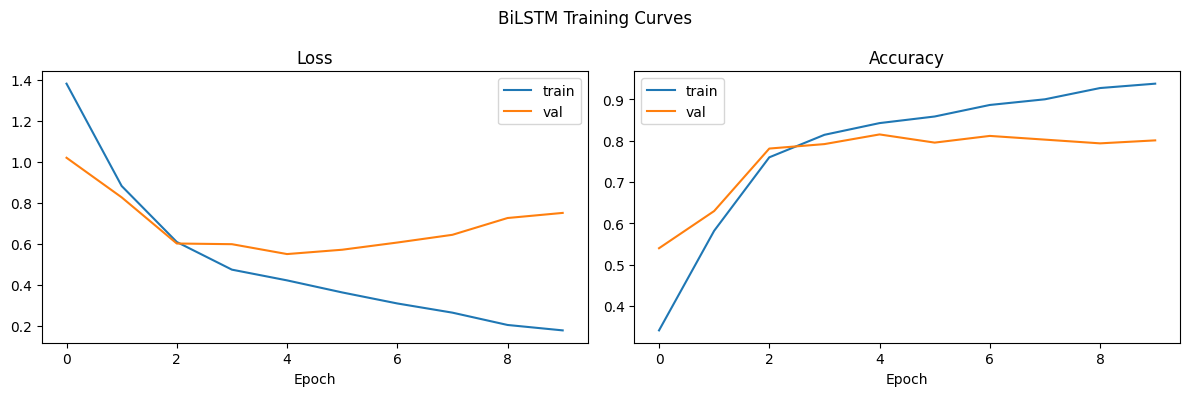

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.suptitle("BiLSTM Training Curves")
plt.tight_layout()
plt.savefig(f"{WORK_DIR}/03_bilstm_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
y_pred_prob = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)

acc    = accuracy_score(y_test, y_pred)
mac_f1 = f1_score(y_test, y_pred, average="macro")
wgt_f1 = f1_score(y_test, y_pred, average="weighted")

report_dict = classification_report(
    y_test, y_pred,
    target_names=LABEL_NAMES,
    digits=3,
    output_dict=True
)
hr_recall = report_dict["high_risk"]["recall"]

print("=" * 60)
print("BiLSTM — Test Set")
print("=" * 60)
print(f"Accuracy          : {acc:.4f}")
print(f"Macro F1          : {mac_f1:.4f}")
print(f"Weighted F1       : {wgt_f1:.4f}")
print(f"Recall(high_risk) : {hr_recall:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=LABEL_NAMES, digits=3))

if hr_recall >= 0.90:
    print("✅ PASS safety gate: Recall(high_risk) >= 0.90")
else:
    print("⚠️  Chưa đạt safety gate, cần tune thêm")

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
BiLSTM — Test Set
Accuracy          : 0.7518
Macro F1          : 0.7771
Weighted F1       : 0.7599
Recall(high_risk) : 1.0000

                    precision    recall  f1-score   support

    normal_support      0.636     0.793     0.706       150
     school_stress      0.974     0.747     0.845       150
relationship_issue      0.895     0.680     0.773       100
         self_care      0.521     0.630     0.570       100
         high_risk      0.982     1.000     0.991        56

          accuracy                          0.752       556
         macro avg      0.802     0.770     0.777       556
      weighted avg      0.788     0.752     0.760       556

✅ PASS safety gate: Recall(high_risk) >= 0.90


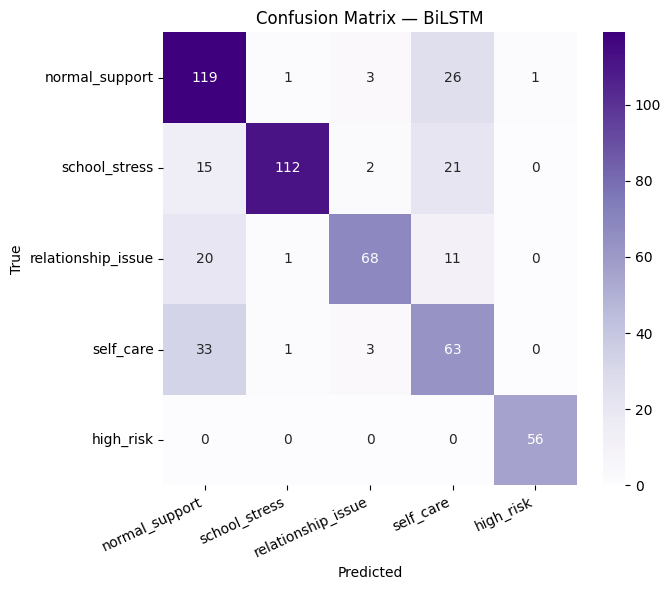

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Purples",
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES
)
plt.title("Confusion Matrix — BiLSTM")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(f"{WORK_DIR}/03_cm_bilstm.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
import pandas as pd

pd.DataFrame([{
    "model": "BiLSTM (TF)",
    "accuracy": acc,
    "macro_f1": mac_f1,
    "weighted_f1": wgt_f1,
    "high_risk_recall": hr_recall,
}]).to_csv(f"{WORK_DIR}/03_bilstm_metrics.csv", index=False)

# Lưu dạng Keras file
model.save(f"{WORK_DIR}/03_bilstm_final.keras")

print("✅ Saved: 03_bilstm_metrics.csv")
print("✅ Saved model: 03_bilstm_final.keras")

✅ Saved: 03_bilstm_metrics.csv
✅ Saved model: 03_bilstm_final.keras


In [ ]:
# ===== Tạo export_model nhận trực tiếp string =====
text_input = tf.keras.Input(shape=(1,), dtype=tf.string, name="text_input")

# Cho TextVectorization xử lý text → sequence int
x = vectorizer(text_input)

# Cho BiLSTM model xử lý tiếp
x = model(x)

export_model = tf.keras.Model(
    inputs=text_input,
    outputs=x,
    name="BiLSTM_SafetyRouter_Export",
)

export_model.summary()

# ===== Lưu export_model dạng .keras =====
EXPORT_PATH = f"{WORK_DIR}/03_bilstm_export.keras"
export_model.save(EXPORT_PATH)

print("✅ Saved export model:", EXPORT_PATH)

Model: "BiLSTM_SafetyRouter_Export"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_input (InputLayer)         │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 128)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BiLSTM_SafetyRouter             │ (None, 5)              │     4,136,709 │
│ (Sequential)                    │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,136,709 (15.78 MB)

 Trainable params: 4,136,709 (15.78 MB)

 Non-trainable params: 0 (0.00 B)

✅ Saved export model: /kaggle/working/03_bilstm_export.keras


In [ ]:
test_texts = test["text"].astype(str).values
wrong_idx = np.where(y_pred != y_test)[0]

print(f"Tổng số mẫu dự đoán sai: {len(wrong_idx)} / {len(y_test)}")

hr_id = LABEL_NAMES.index("high_risk")
priority_wrong = [i for i in wrong_idx if y_test[i] == hr_id or y_pred[i] == hr_id]

show_idx = priority_wrong[:5] if len(priority_wrong) >= 5 else list(wrong_idx[:5])

print("\n--- 5 lỗi tiêu biểu ---")
for i in show_idx:
    print(f"\n[{i}]")
    print("Text   :", test_texts[i][:200])
    print("True   :", LABEL_NAMES[y_test[i]])
    print("Predict:", LABEL_NAMES[y_pred[i]])

Tổng số mẫu dự đoán sai: 138 / 556

--- 5 lỗi tiêu biểu ---

[2]
Text   : Tôi đã nghĩ về điều đó nhưng việc thực hiện bước đó khiến tôi cảm thấy khó khăn. Tôi lo lắng về việc dễ bị tổn thương với người mà tôi không quen biết, và nếu họ không thể giúp tôi thì sao?
True   : normal_support
Predict: relationship_issue

[3]
Text   : Tôi đã cố gắng nhưng tôi gặp khó khăn trong việc thể hiện bản thân. Tôi cảm thấy như mình thường xuyên gặp khó khăn và tôi không muốn tạo thêm gánh nặng cho họ nữa. Đó là một cuộc đấu tranh để tìm nhữ
True   : school_stress
Predict: normal_support

[16]
Text   : Cảm ơn. Bây giờ tôi cảm thấy hy vọng hơn. Tôi đoán điều cuối cùng tôi muốn giải quyết là các triệu chứng thể chất đi kèm với sự lo lắng của tôi. Tôi thường xuyên cảm thấy tim đập nhanh và khó thở. Nó 
True   : school_stress
Predict: normal_support

[19]
Text   : Vâng, tôi có. Chúng tôi đã có một vài cuộc thảo luận về những thách thức mà chúng tôi đang phải đối mặt và cô ấy có cùng mong muốn về hòa bình v